In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [32]:
def load_usb_csv(csv_path: Path) -> np.ndarray:
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    if data.ndim == 1:
        data = data[:, np.newaxis]
    return data.astype(np.float64)

In [33]:
calib_path = Path("run_2_calib.csv")
calib_data = load_usb_csv(calib_path)
print("Calibration Data Shape:", calib_data.shape)

press_path_close = Path("run_2_close_press.csv")
press_data_close = load_usb_csv(press_path_close)
print("Close Press Data Shape:", press_data_close.shape)

press_path_mid = Path("run_2_middle_press.csv")
press_data_mid = load_usb_csv(press_path_mid)
print("Mid Press Data Shape:", press_data_mid.shape)

press_path_far = Path("run_2_edge_press.csv")
press_data_far = load_usb_csv(press_path_far)
print("Far Press Data Shape:", press_data_far.shape)



calib_data = calib_data * (3.3 / 4095)  # convert to voltage
press_data_close = press_data_close * (3.3 / 4095)  # convert to voltage
press_data_mid = press_data_mid * (3.3 / 4095)  # convert to voltage
press_data_far = press_data_far * (3.3 / 4095)  #
time = np.arange(len(calib_data)) * (1/6.25)  # time vector based on sampling rate

Calibration Data Shape: (766, 1000)
Close Press Data Shape: (766, 1000)
Mid Press Data Shape: (766, 1000)
Far Press Data Shape: (766, 1000)


Expected edge time: 96.62 us


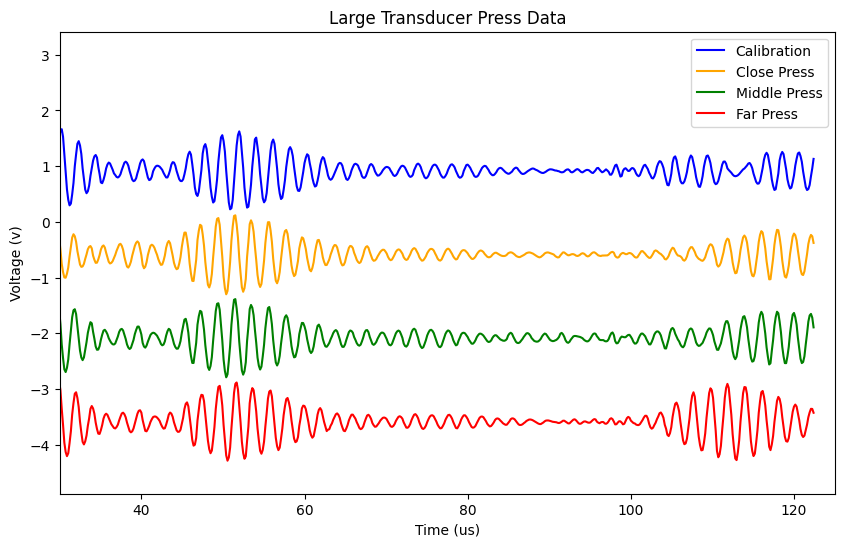

In [56]:
# plot calibration and press data over time

calib = calib_data[:, 1]
press_close = press_data_close[:, 3]
press_mid = press_data_mid[:, 9]
press_far = press_data_far[:, 4]

c = 1449
l = 0.07

edge_time = 2 * l / c * 1e6 # in microseconds
print(f"Expected edge time: {edge_time:.2f} us")


plt.figure(figsize=(10, 6))
plt.plot(time, calib, label='Calibration', color='blue')
plt.plot(time, press_close - 1.5, label='Close Press', color='orange')
plt.plot(time, press_mid - 3, label='Middle Press', color='green')
plt.plot(time, press_far - 4.5, label='Far Press', color='red')
# plt.plot(time, shifted_press, label='Press', color='orange')
plt.title('Large Transducer Press Data')  
# plt.title('Calibration vs Press Data')  
# plt.legend()
plt.xlabel('Time (us)')
plt.ylabel('Voltage (v)')
# plt.axvline(x=edge_time, color='red', linestyle='--', label='Expected Edge Time')
# plt.axvline(x=102, color='orange', linestyle='--', label='Actual Edge Time')
# plt.axvline(x=25, color='cyan', linestyle='--', label='Acutal Press Time')
plt.xlim(30, 125)  # set x-axis limits for better visualization
# plt.ylim(0.6, 1.3)  # set y-axis limits
plt.legend()
plt.show()